In [ ]:
pip install kagglehub tf-keras

Iniciando o download do dataset...
Using Colab cache for faster access to the 'flowers-dataset' dataset.
Caminho para os arquivos do dataset: /kaggle/input/flowers-dataset
Total de imagens encontradas: 3670
Treino: 2568 | Validação: 551 | Teste: 551
Found 2568 validated image filenames belonging to 5 classes.
Found 551 validated image filenames belonging to 5 classes.
Found 551 validated image filenames belonging to 5 classes.
Iniciando treinamento...
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 287ms/step - accuracy: 0.7870 - loss: 0.5763 - val_accuracy: 0.8566 - val_loss: 0.4099
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.9171 - loss: 0.2542 - val_accuracy: 0.8548 - val_loss: 0.4385
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9548 - loss: 0.1680 - val_accuracy: 0.8603 - val_loss: 0.4034
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.9712 - loss: 0.1076 - val_accuracy: 0.8621 - val_loss: 0.4054
Epoch 5/10
81/81 ━━━━━━━━━━━

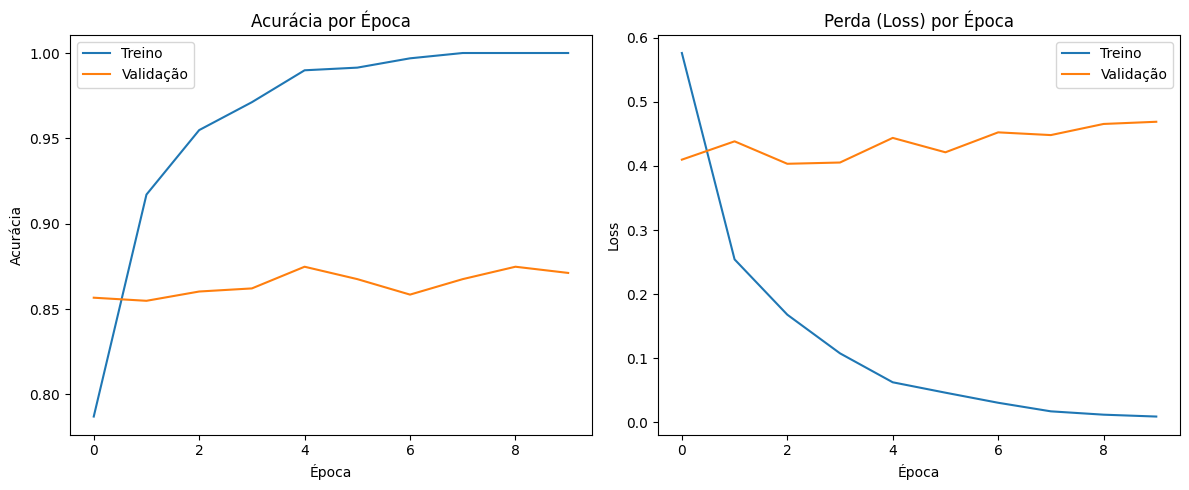

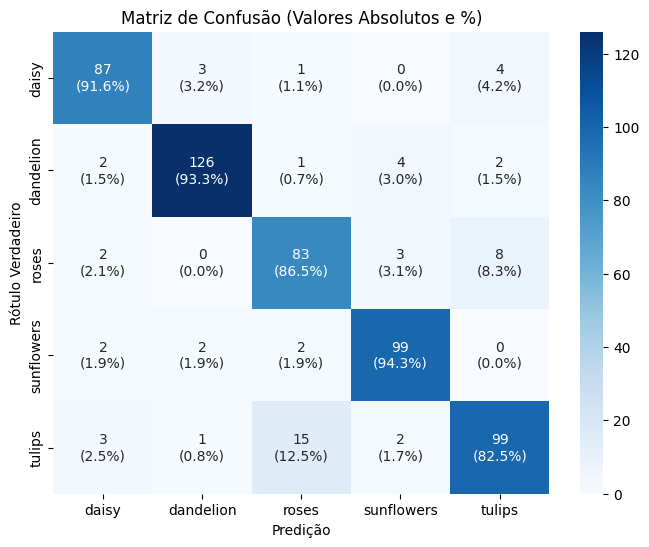

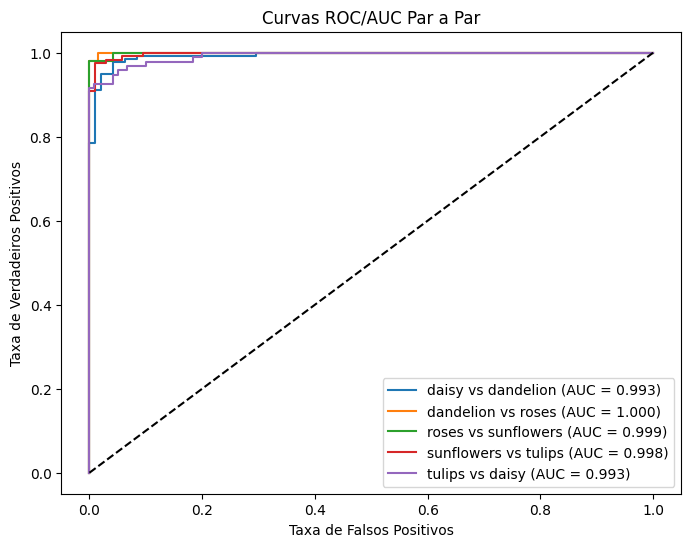

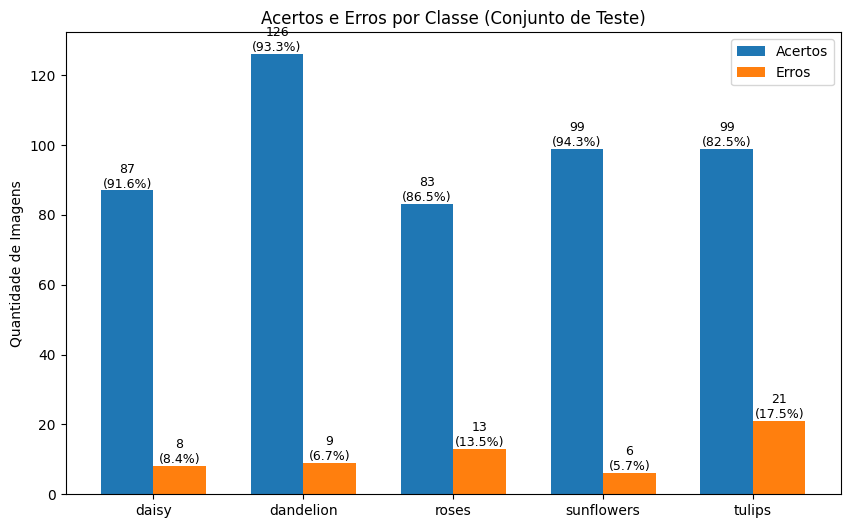

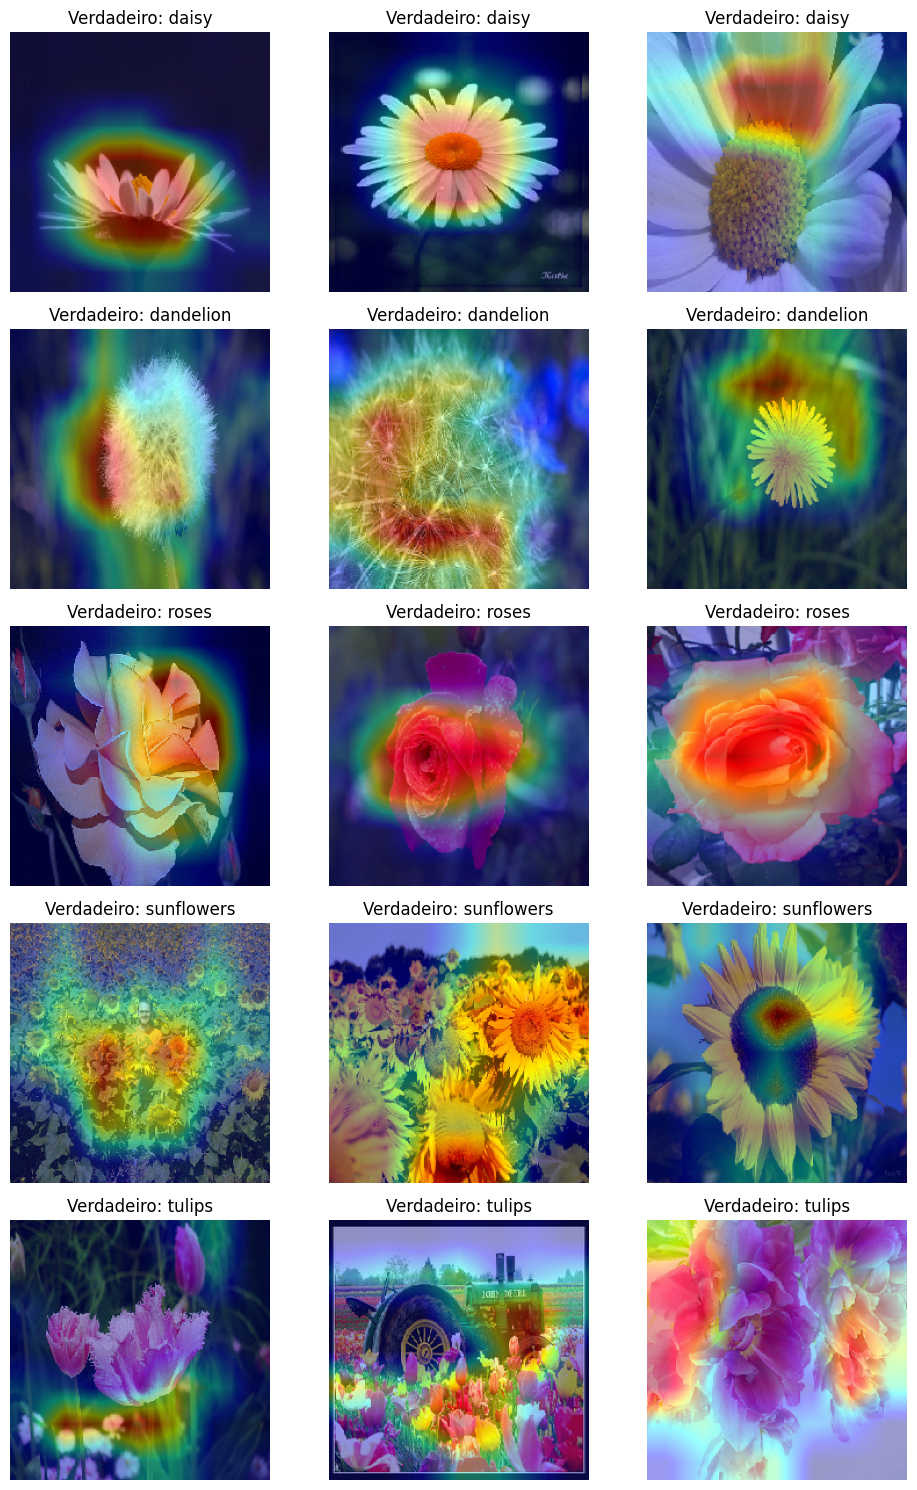

In [8]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import cv2
import kagglehub

print("Iniciando o download do dataset...")
path = kagglehub.dataset_download("rahmasleam/flowers-dataset")

print("Caminho para os arquivos do dataset:", path)

dataset_dir = path
img_size = (224, 224)
batch_size = 32
classes_alvo = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

filepaths = []
labels = []

for root, dirs, files in os.walk(dataset_dir):
    pasta_atual = os.path.basename(root).lower()

    if pasta_atual in classes_alvo:
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepaths.append(os.path.join(root, file))
                labels.append(pasta_atual)

print(f"Total de imagens encontradas: {len(filepaths)}")
if len(filepaths) == 0:
    raise ValueError("ERRO: Nenhuma imagem encontrada. Verifique o download do Kagglehub.")

X_train_val, X_test, y_train_val, y_test = train_test_split(filepaths, labels, test_size=0.15, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42, stratify=y_train_val)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")

train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
val_df = pd.DataFrame({'filename': X_val, 'class': y_val})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='class', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=True)
val_gen = datagen.flow_from_dataframe(val_df, x_col='filename', y_col='class', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)
test_gen = datagen.flow_from_dataframe(test_df, x_col='filename', y_col='class', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Iniciando treinamento...")
start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

end_time = time.time()
training_time_minutes = (end_time - start_time) / 60
print(f"\n[Item h] Tempo total de treinamento e validação: {training_time_minutes:.2f} minutos")

y_pred_probs = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.array(test_gen.classes)

acc = accuracy_score(y_true_classes, y_pred_classes)
prec = precision_score(y_true_classes, y_pred_classes, average='macro')
rec = recall_score(y_true_classes, y_pred_classes, average='macro')
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')

print("\n[Item c] Métricas de Classificação no Conjunto de Teste:")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Revocação: {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history.history['accuracy'], label='Treino')
ax[0].plot(history.history['val_accuracy'], label='Validação')
ax[0].set_title('Acurácia por Época')
ax[0].set_ylabel('Acurácia')
ax[0].set_xlabel('Época')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Treino')
ax[1].plot(history.history['val_loss'], label='Validação')
ax[1].set_title('Perda (Loss) por Época')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Época')
ax[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels_names = list(test_gen.class_indices.keys())
annot_data = [f"{v1}\n({v2:.1f}%)" for v1, v2 in zip(cm.flatten(), cm_percent.flatten())]
annot_data = np.asarray(annot_data).reshape(5, 5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot_data, fmt='', cmap='Blues', xticklabels=labels_names, yticklabels=labels_names)
plt.title('Matriz de Confusão (Valores Absolutos e %)')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Predição')
plt.show()

pares = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]
nomes = labels_names

plt.figure(figsize=(8, 6))
for (c1, c2) in pares:
    mask = (y_true_classes == c1) | (y_true_classes == c2)
    if np.sum(mask) == 0: continue

    y_true_pair = (y_true_classes[mask] == c2).astype(int)

    probs_c1 = y_pred_probs[mask, c1]
    probs_c2 = y_pred_probs[mask, c2]
    probs_pair = probs_c2 / (probs_c1 + probs_c2 + 1e-7)

    fpr, tpr, _ = roc_curve(y_true_pair, probs_pair)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{nomes[c1]} vs {nomes[c2]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC/AUC Par a Par')
plt.legend(loc='lower right')
plt.show()

acertos = np.diag(cm)
erros = cm.sum(axis=1) - acertos
total = cm.sum(axis=1)

acertos_pct = (acertos / total) * 100
erros_pct = (erros / total) * 100

x_pos = np.arange(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x_pos - width/2, acertos, width, label='Acertos')
rects2 = ax.bar(x_pos + width/2, erros, width, label='Erros')

ax.set_ylabel('Quantidade de Imagens')
ax.set_title('Acertos e Erros por Classe (Conjunto de Teste)')
ax.set_xticks(x_pos)
ax.set_xticklabels(nomes)
ax.legend()

for i, rect in enumerate(rects1):
    ax.annotate(f"{acertos[i]}\n({acertos_pct[i]:.1f}%)", (rect.get_x() + rect.get_width()/2, rect.get_height()), ha='center', va='bottom', fontsize=9)
for i, rect in enumerate(rects2):
    ax.annotate(f"{erros[i]}\n({erros_pct[i]:.1f}%)", (rect.get_x() + rect.get_width()/2, rect.get_height()), ha='center', va='bottom', fontsize=9)

plt.show()

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

last_conv_layer = 'out_relu'

fig, axes = plt.subplots(5, 3, figsize=(10, 15))
for i, label in enumerate(labels_names):
    class_indices = np.where(y_true_classes == i)[0][:3]
    for j, idx in enumerate(class_indices):
        img_path = test_df.iloc[idx]['filename']
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array_preprocessed = np.expand_dims(img_array, axis=0) / 255.0
        img_tensor = tf.convert_to_tensor(img_array_preprocessed, dtype=tf.float32)

        heatmap = make_gradcam_heatmap(img_tensor, model, last_conv_layer)

        heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(np.array(img)[:,:,::-1], 0.6, heatmap, 0.4, 0)

        ax = axes[i, j]
        ax.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Verdadeiro: {label}")
        ax.axis('off')

plt.tight_layout()
plt.show()